# YOLOv8 Sickle Cell Detector — Local Dataset

Trains a **YOLOv8 detection model** on a small local dataset (26 images) with
Roboflow YOLO-format bounding box annotations.

This model detects and localizes sickle-shaped cells in blood smear images.

## Output
- `scd_yolov8_local_detect.pt`

In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================
!pip -q install ultralytics

import os
import shutil
import yaml
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 0:
    !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

Mounted at /content/drive
Device: 0
Tesla T4, 15360 MiB


In [2]:
# ============================================================
# CELL 2: Configuration & Dataset Verification
# ============================================================

# Path to your local dataset (Roboflow YOLO export)
DATASET_ROOT = '/content/drive/MyDrive/SCD/SCD_LocalDataset'

# Model save location
MODEL_SAVE_DIR = '/content/drive/MyDrive/SCD'

# Verify dataset structure
print('Dataset structure:')
for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = '  ' * (level + 1)
    # Show file count instead of listing all files
    img_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    txt_files = [f for f in files if f.endswith('.txt') and f != 'classes.txt']
    other_files = [f for f in files if f not in img_files and f not in txt_files]
    if img_files:
        print(f'{sub_indent}{len(img_files)} images')
    if txt_files:
        print(f'{sub_indent}{len(txt_files)} label files')
    for f in other_files:
        print(f'{sub_indent}{f}')

Dataset structure:
SCD_LocalDataset/
  2 label files
  data.yaml
  valid/
    labels/
      2 label files
    images/
      2 images
  train/
    labels/
      21 label files
    images/
      21 images
  test/
    labels/
      3 label files
    images/
      3 images


: 

In [3]:
# ============================================================
# CELL 3: Read & Fix data.yaml
# ============================================================

# Read existing data.yaml from Roboflow
data_yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')

with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print('Original data.yaml:')
print(data_config)

# Fix paths to point to Google Drive location
data_config['path'] = DATASET_ROOT
data_config['train'] = 'train/images'
data_config['val'] = 'valid/images'
data_config['test'] = 'test/images'

# Write fixed data.yaml
fixed_yaml_path = os.path.join(DATASET_ROOT, 'data_fixed.yaml')
with open(fixed_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f'\nFixed data.yaml saved to: {fixed_yaml_path}')
print('Contents:')
print(open(fixed_yaml_path).read())

# Extract class info
NUM_CLASSES = data_config.get('nc', len(data_config.get('names', [])))
CLASS_NAMES = data_config.get('names', [])
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
print(f'\nClasses ({NUM_CLASSES}): {CLASS_NAMES}')

Original data.yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['Sickle'], 'roboflow': {'workspace': 'nisithas-workspace', 'project': 'scd-llwh4', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/nisithas-workspace/scd-llwh4/dataset/1'}}

Fixed data.yaml saved to: /content/drive/MyDrive/SCD/SCD_LocalDataset/data_fixed.yaml
Contents:
names:
- Sickle
nc: 1
path: /content/drive/MyDrive/SCD/SCD_LocalDataset
roboflow:
  license: CC BY 4.0
  project: scd-llwh4
  url: https://universe.roboflow.com/nisithas-workspace/scd-llwh4/dataset/1
  version: 1
  workspace: nisithas-workspace
test: test/images
train: train/images
val: valid/images


Classes (1): ['Sickle']


: 

In [4]:
# ============================================================
# CELL 4: Inspect Annotations
# ============================================================

def count_annotations(split_dir):
    """Count images and annotations in a split."""
    img_dir = os.path.join(split_dir, 'images')
    lbl_dir = os.path.join(split_dir, 'labels')
    
    if not os.path.isdir(img_dir):
        return 0, 0, {}
    
    n_images = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    
    n_boxes = 0
    class_counts = {}
    if os.path.isdir(lbl_dir):
        for lbl_file in os.listdir(lbl_dir):
            if not lbl_file.endswith('.txt'):
                continue
            with open(os.path.join(lbl_dir, lbl_file)) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        n_boxes += 1
                        cls_id = int(parts[0])
                        class_counts[cls_id] = class_counts.get(cls_id, 0) + 1
    
    return n_images, n_boxes, class_counts

print('Dataset Statistics:')
print('-' * 50)
total_boxes = 0
for split in ['train', 'valid', 'test']:
    split_dir = os.path.join(DATASET_ROOT, split)
    n_img, n_box, cls_counts = count_annotations(split_dir)
    total_boxes += n_box
    cls_str = ', '.join([f'{CLASS_NAMES[k] if k < len(CLASS_NAMES) else k}: {v}' for k, v in sorted(cls_counts.items())])
    print(f'  {split:>6}: {n_img} images, {n_box} boxes  [{cls_str}]')

print(f'\n  Total bounding boxes: {total_boxes}')
print(f'  Avg boxes per image: {total_boxes / 26:.1f}')

Dataset Statistics:
--------------------------------------------------
   train: 21 images, 27 boxes  [Sickle: 27]
   valid: 2 images, 2 boxes  [Sickle: 2]
    test: 3 images, 3 boxes  [Sickle: 3]

  Total bounding boxes: 32
  Avg boxes per image: 1.2


: 

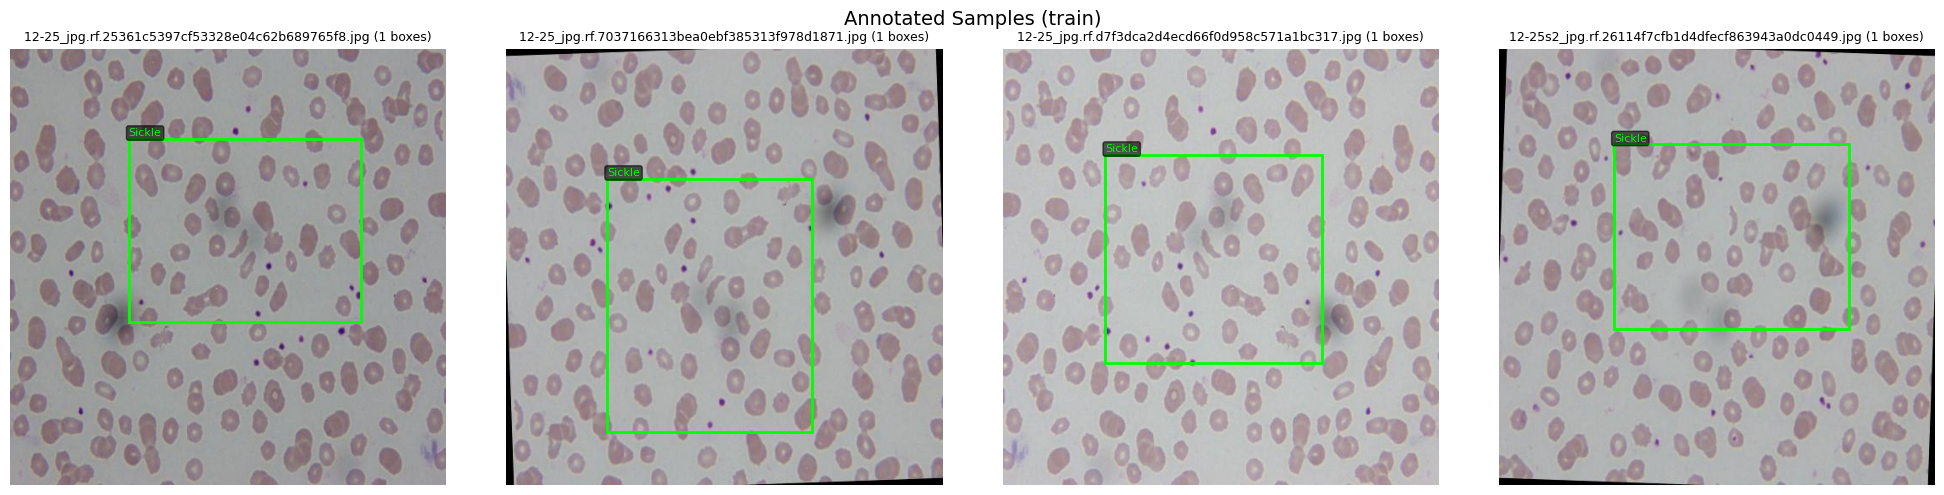

: 

In [5]:
# ============================================================
# CELL 5: Visualize Annotated Samples
# ============================================================

def show_annotated(split='train', n=4):
    img_dir = os.path.join(DATASET_ROOT, split, 'images')
    lbl_dir = os.path.join(DATASET_ROOT, split, 'labels')
    
    img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    samples = img_files[:n]
    
    fig, axes = plt.subplots(1, min(n, len(samples)), figsize=(5 * min(n, len(samples)), 5))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    
    colors = ['lime', 'red', 'cyan', 'yellow', 'magenta']
    
    for ax, fn in zip(axes, samples):
        img = Image.open(os.path.join(img_dir, fn))
        w_img, h_img = img.size
        ax.imshow(img)
        
        lbl_fn = os.path.splitext(fn)[0] + '.txt'
        lbl_path = os.path.join(lbl_dir, lbl_fn)
        n_boxes = 0
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x1 = (cx - bw/2) * w_img
                    y1 = (cy - bh/2) * h_img
                    color = colors[cls_id % len(colors)]
                    rect = patches.Rectangle(
                        (x1, y1), bw * w_img, bh * h_img,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                    ax.text(x1, y1 - 3, label, color=color, fontsize=8,
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6))
                    n_boxes += 1
        
        ax.set_title(f'{fn} ({n_boxes} boxes)', fontsize=9)
        ax.axis('off')
    
    plt.suptitle(f'Annotated Samples ({split})', fontsize=14)
    plt.tight_layout()
    plt.show()

show_annotated('train', 4)

In [6]:
# ============================================================
# CELL 6: Train YOLOv8 Detection Model
# ============================================================
# With only 26 images, we rely HEAVILY on:
#   - Pretrained weights (COCO)
#   - Aggressive augmentation
#   - Many epochs (the model needs to see augmented versions many times)
#   - Small model (nano) to prevent overfitting

model = YOLO('yolov8n.pt')  # YOLOv8 nano — smallest, best for tiny datasets

results = model.train(
    data=fixed_yaml_path,
    epochs=150,               # Many epochs — small dataset needs more passes
    imgsz=640,
    batch=8,                  # Small batch for small dataset
    device=DEVICE,
    patience=30,              # Long patience — let augmentation work
    workers=2,
    project=os.path.join(DATASET_ROOT, 'runs'),
    name='yolov8_detect',
    exist_ok=True,
    # Heavy augmentation for small dataset
    hsv_h=0.02,              # Hue variation
    hsv_s=0.7,               # Saturation variation
    hsv_v=0.4,               # Value/brightness variation
    degrees=30,              # Rotation
    translate=0.2,           # Translation
    scale=0.5,               # Scale variation
    shear=10,                # Shear
    flipud=0.5,              # Vertical flip
    fliplr=0.5,              # Horizontal flip
    mosaic=1.0,              # Mosaic augmentation (crucial for small datasets)
    mixup=0.2,               # Mixup
    copy_paste=0.1,          # Copy-paste augmentation
    verbose=True,
)

print('Training complete.')

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SCD/SCD_LocalDataset/data_fixed.yaml, degrees=30, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_detect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

: 

In [7]:
# ============================================================
# CELL 7: Evaluate Model
# ============================================================

BEST_PT = os.path.join(DATASET_ROOT, 'runs', 'yolov8_detect', 'weights', 'best.pt')

if not os.path.exists(BEST_PT):
    # Search for it
    for r, d, files in os.walk(os.path.join(DATASET_ROOT, 'runs')):
        if 'best.pt' in files:
            BEST_PT = os.path.join(r, 'best.pt')
            print(f'Found: {BEST_PT}')
            break

detector = YOLO(BEST_PT)

# Validate
print('=== Validation Metrics ===')
val_metrics = detector.val(
    data=fixed_yaml_path,
    split='val',
    imgsz=640,
    device=DEVICE,
    verbose=True
)
print(f'mAP50:    {val_metrics.box.map50:.4f}')
print(f'mAP50-95: {val_metrics.box.map:.4f}')

# Test
print('\n=== Test Metrics ===')
test_metrics = detector.val(
    data=fixed_yaml_path,
    split='test',
    imgsz=640,
    device=DEVICE,
    verbose=True
)
print(f'mAP50:    {test_metrics.box.map50:.4f}')
print(f'mAP50-95: {test_metrics.box.map:.4f}')

=== Validation Metrics ===
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.2 ms, read: 25.9±7.0 MB/s, size: 30.4 KB)
val: Scanning /content/drive/MyDrive/SCD/SCD_LocalDataset/valid/labels.cache... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 645.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 12.7it/s 0.1s
                   all          2          2    0.00333          1      0.995      0.846
Speed: 1.0ms preprocess, 26.6ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val
mAP50:    0.9950
mAP50-95: 0.8455

=== Test Metrics ===
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.1±0.0 MB/s, size: 29.3 KB)
val: Scanning /con

: 

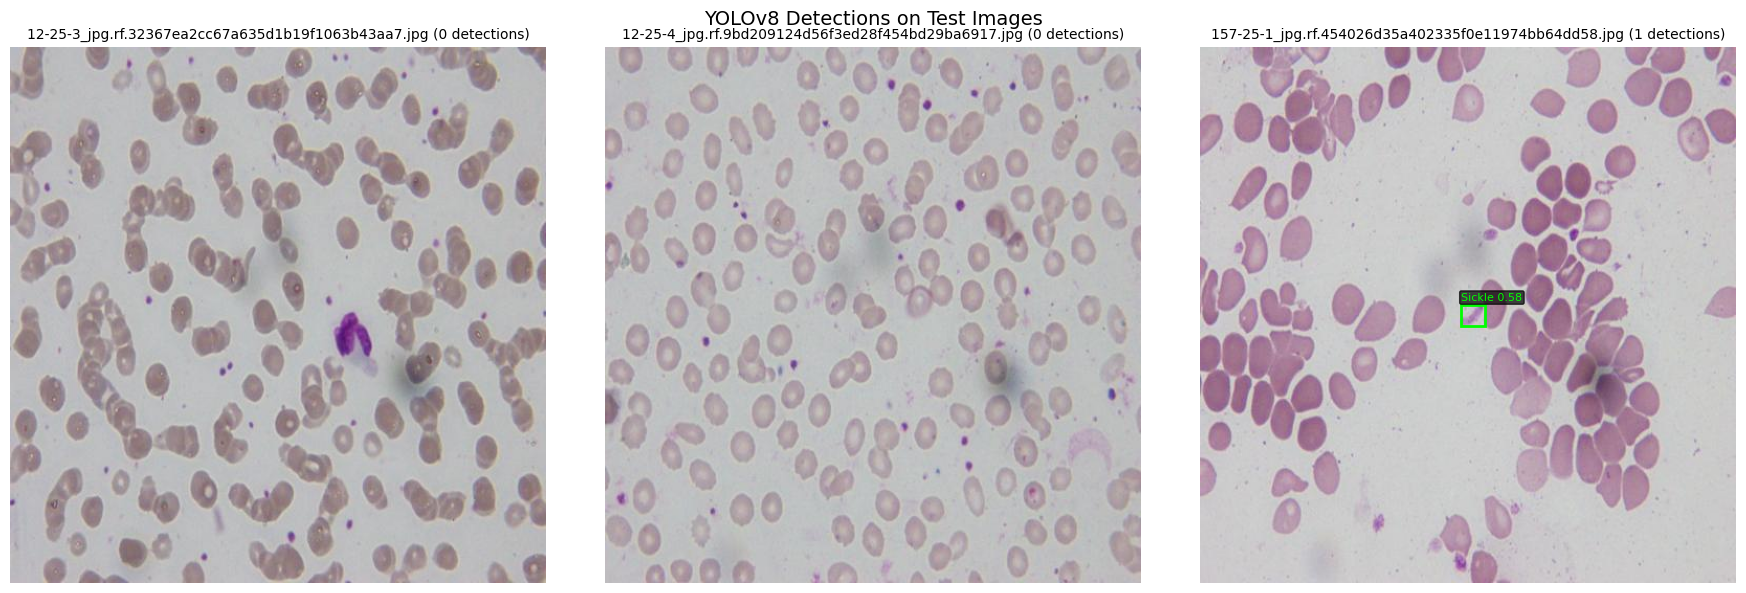

: 

In [8]:
# ============================================================
# CELL 8: Visualize Detections on Test Images
# ============================================================

test_img_dir = os.path.join(DATASET_ROOT, 'test', 'images')
test_imgs = sorted([f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

n = min(len(test_imgs), 6)
cols = min(n, 3)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
if n == 1:
    axes = np.array([axes])
axes = np.array(axes).flatten()

colors_map = ['lime', 'red', 'cyan', 'yellow', 'magenta']

for i, fn in enumerate(test_imgs[:n]):
    img_path = os.path.join(test_img_dir, fn)
    results = detector.predict(img_path, imgsz=640, conf=0.25, device=DEVICE, verbose=False)
    r = results[0]

    img = Image.open(img_path)
    axes[i].imshow(img)

    if r.boxes is not None:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].item()
            cls_id = int(box.cls[0].item())
            color = colors_map[cls_id % len(colors_map)]
            label = f'{CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else cls_id} {conf:.2f}'

            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            axes[i].add_patch(rect)
            axes[i].text(x1, y1 - 4, label, color=color, fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.7))

    n_det = len(r.boxes) if r.boxes is not None else 0
    axes[i].set_title(f'{fn} ({n_det} detections)', fontsize=10)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('YOLOv8 Detections on Test Images', fontsize=14)
plt.tight_layout()
plt.show()

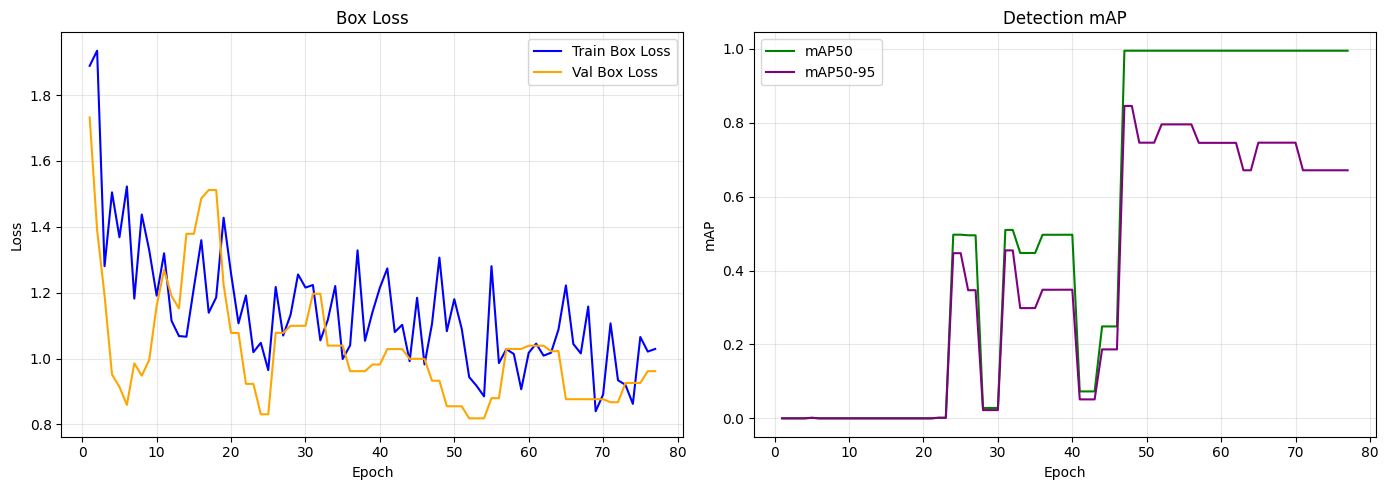

: 

In [9]:
# ============================================================
# CELL 9: Plot Training Curves
# ============================================================

import csv

results_csv = os.path.join(DATASET_ROOT, 'runs', 'yolov8_detect', 'results.csv')

if os.path.exists(results_csv):
    with open(results_csv, 'r') as f:
        reader = csv.reader(f)
        headers = [h.strip() for h in next(reader)]
        rows = [[c.strip() for c in row] for row in reader if row]

    data = {h: [] for h in headers}
    for row in rows:
        for h, val in zip(headers, row):
            try:
                data[h].append(float(val))
            except ValueError:
                data[h].append(0.0)

    def find_col(keyword):
        for h in headers:
            if keyword in h:
                return h
        return None

    epoch_col = find_col('epoch')
    box_loss_col = find_col('train/box_loss')
    val_box_col = find_col('val/box_loss')
    map50_col = find_col('metrics/mAP50(B)')
    map_col = find_col('metrics/mAP50-95(B)')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if epoch_col and box_loss_col:
        axes[0].plot(data[epoch_col], data[box_loss_col], label='Train Box Loss', color='blue')
    if epoch_col and val_box_col:
        axes[0].plot(data[epoch_col], data[val_box_col], label='Val Box Loss', color='orange')
    axes[0].set_title('Box Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if epoch_col and map50_col:
        axes[1].plot(data[epoch_col], data[map50_col], label='mAP50', color='green')
    if epoch_col and map_col:
        axes[1].plot(data[epoch_col], data[map_col], label='mAP50-95', color='purple')
    axes[1].set_title('Detection mAP')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(f'results.csv not found: {results_csv}')

In [10]:
# ============================================================
# CELL 10: Save Final Model
# ============================================================

FINAL_PATH = os.path.join(MODEL_SAVE_DIR, 'scd_yolov8_local_detect.pt')
shutil.copy(BEST_PT, FINAL_PATH)
print(f'Model saved: {FINAL_PATH}')
print(f'File size: {os.path.getsize(FINAL_PATH) / 1024 / 1024:.1f} MB')

# Quick verify
test_model = YOLO(FINAL_PATH)
print(f'Task: {test_model.task}')
print(f'Classes: {test_model.names}')

sample = os.path.join(test_img_dir, test_imgs[0])
r = test_model.predict(sample, imgsz=640, conf=0.25, device=DEVICE, verbose=False)[0]
print(f'Sample: {len(r.boxes)} detections')
print(f'\nDone. scd_yolov8_local_detect.pt is ready.')

Model saved: /content/drive/MyDrive/SCD/scd_yolov8_local_detect.pt
File size: 6.0 MB
Task: detect
Classes: {0: 'Sickle'}
Sample: 0 detections

Done. scd_yolov8_local_detect.pt is ready.


: 